In [44]:
from genelens.netanalyzer import GeneralNet, Targets, tissue_selector
from tqdm import tqdm
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from reactome2py import content
import json
import seaborn as sns

miRTargets = Targets()

def get_genes_in_pathway(pathway_id):
    ref_entities = content.participants_reference_entities(pathway_id)
    
    genes = set()
    for entity in ref_entities:
        if "geneName" in entity and entity["geneName"]:
            genes.add(entity["geneName"][0])
    
    return sorted(genes)

# Пример использования
# pathway_id = "R-HSA-448424"  # Interleukin-4 and Interleukin-13 signaling
# genes = get_genes_in_pathway(pathway_id)

def set_distance(A, B):
    keys_A = list(A.keys())
    keys_B = list(B.keys())

    # Матрица расстояний: C[i][j] = стоимость сопоставить A[i] с B[j]
    C = np.zeros((len(keys_A), len(keys_B)))

    for i, k1 in enumerate(keys_A):
        for j, k2 in enumerate(keys_B):
            if k1 == k2:
                C[i][j] = np.abs(A[k1] - B[k2])
            else:
                C[i][j] = A[k1] + B[k2]       # иначе полная цена замены

    row_ind, col_ind = linear_sum_assignment(C)

    # вывод сопоставлений
    #for i, j in zip(row_ind, col_ind):
    #    print(f"{keys_A[i]} ↔ {keys_B[j]}, cost = {C[i][j]:.2f}")

    # Общая стоимость
    total_cost = C[row_ind, col_ind].sum()
    return total_cost

def set_distance_loss(Path_w, miR_w, P=1, M=1/2):
    loss = 0
    path_gene = set(Path_w.keys())
    mir_gene = set(miR_w.keys())
    if not mir_gene or not path_gene:
        return 0
    common_genes = path_gene.intersection(mir_gene)
    if not common_genes:
        return 0
    if not P or not M:
        P = len(mir_gene)/len(path_gene)
        M = len(path_gene)/len(mir_gene)
    
    for gene in common_genes:
        loss += np.abs(Path_w[gene] - miR_w[gene])
    for gene in path_gene.difference(common_genes):
        loss += Path_w[gene] * P
    for gene in mir_gene.difference(common_genes):
        loss += miR_w[gene] * M
    return loss
    


def get_weighted_G(target_nodes, tissue_gene):
    G = GeneralNet(verbose=False)
    G.select_nodes(target_nodes)
    G.select_nodes(tissue_gene)
    G.get_LCC(verbose=False)
    G_weight = G.get_LCCnd_centrality()
    if not G_weight:
        return dict()
    # нормализация к максимальному значению
    max_value = max(G_weight.values())
    if max_value == 0:
        normalized_values = {k: 0 for k in G_weight}
    else:
        normalized_values = {k: v / max_value for k, v in G_weight.items()}
    return normalized_values

# настройки рисования
hist_param = {'bins': 20, 
              'color': '#FF7F50', 
              'edgecolor': 'black', 
              'alpha': 0.85}
scatter_param = {'color': '#FF7F50', 
                 'edgecolor': 'black', 
                 'alpha': 0.85}
line_param = {'color': '#FF7F50', 
                 'alpha': 0.85}
title_param = {'fontsize': 12,
               'fontweight': 'bold'}
label_param = {'fontsize': 10}
ticks_param = {'axis': 'both', 
               'labelsize': 9}
sns.set_style("whitegrid")
FIG_DIST = 'paper/Figs/'

path_to_miRTarBase not specified. miRTarbase built-in version loaded


In [68]:
path_ids = ['R-HSA-202127', 
           'R-HSA-1234174.5', 
           'R-HSA-194138.4', 
           'R-HSA-190236.4', 
           'R-HSA-186797.6', 
           'R-HSA-2404192.5', 
           'R-HSA-451927.7', 
           'R-HSA-75893.10']

pathway_names = {
    "R-HSA-1234174.5": "Сигнальный путь HIF-1a",
    "R-HSA-194138.4": "Сигнальный путь VEGF",
    "R-HSA-190236.4": "Сигнальный путь FGF2",
    "R-HSA-186797.6": "Сигнальный путь PDGF",
    "R-HSA-2404192.5": "Сигнальный путь IGF-1",
    "R-HSA-451927.7": "Сигнальный путь IL2",
    "R-HSA-75893.10": "Сигнальный путь TNF-a",
    "R-HSA-202127": "Сигнальный путь eNOS",
    "R-HSA-6783589.8": "Сигнальный путь IL6",
    "R-HSA-448424.8": "Сигнальный путь IL17"
}

In [14]:
heart_genes = tissue_selector(ans=0, tissue_id=23)
reactome_db = dict.fromkeys(path_ids)
for path in path_ids:
    reactome_db[path] = get_weighted_G(get_genes_in_pathway(path), heart_genes)
with open('reactome_path_gene.json', 'w', encoding='utf-8') as f:
    json.dump(reactome_db, f, ensure_ascii=False, indent=4)

Gene universe is...
heart muscle was used
your tissue is  heart muscle  number of genes:  7944


In [83]:
result = dict()
heart_genes = tissue_selector(ans=0, tissue_id=23)

for path in path_ids:
    #kegg_G = get_weighted_G(get_genes_in_pathway(path), heart_genes)
    kegg_G = reactome_db[path]
    print(f'{path}, найдено {len(kegg_G)} генов')
    result[path] = dict()
    for miR in tqdm(miRTargets.miR_dict.keys(), desc='miRNA: '):
        miR_genes = miRTargets.get_targets(miR, verbose=False)
        miR_G = get_weighted_G(miR_genes, heart_genes)
        result[path][miR] = set_distance_loss(kegg_G, miR_G)

with open('pathway_miR_dict_norm_loss.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

Gene universe is...
heart muscle was used
your tissue is  heart muscle  number of genes:  7944
R-HSA-202127, найдено 1 генов


miRNA:  13%|█▎        | 344/2599 [01:39<10:29,  3.58it/s]

miRNA:  15%|█▌        | 395/2599 [01:53<09:58,  3.68it/s]

miRNA:  91%|█████████▏| 2378/2599 [11:08<01:01,  3.62it/s]

miRNA:  92%|█████████▏| 2381/2599 [11:09<01:00,  3.59it/s]

...

miRNA:  92%|█████████▏| 2381/2599 [15:07<00:56,  3.84it/s]

miRNA:  98%|█████████▊| 2545/2599 [15:50<00:14,  3.85it/s]

miRNA:  99%|█████████▉| 2585/2599 [16:01<00:03,  3.81it/s]

miRNA: 100%|█████████▉| 2594/2599 [16:03<00:01,  3.77it/s]

miRNA: 100%|██████████| 2599/2599 [16:04<00:00,  2.69it/s]


In [ ]:
with open('pathway_miR_dict_norm_loss.json', 'r', encoding='utf-8') as f:
    result = json.load(f)  # data_dict теперь содержит данные в виде словаря

In [4]:
heart_genes = tissue_selector(ans=0, tissue_id=23)
print('Сигнальный путь;размерность LCC')
for path in result.keys():
    print(path, len(get_weighted_G(get_genes_in_pathway(path), heart_genes)), sep=';')
print()
print(get_genes_in_pathway('R-HSA-202127'))

Gene universe is...
heart muscle was used
your tissue is  heart muscle  number of genes:  7944
Сигнальный путь;размерность LCC
R-HSA-202127;1
R-HSA-1234174.5;40
R-HSA-194138.4;53
R-HSA-190236.4;35
R-HSA-186797.6;19
R-HSA-2404192.5;13
R-HSA-451927.7;12
R-HSA-75893.10;33

['AKT1', 'CALM1', 'HSP90AA1', 'NOS3']


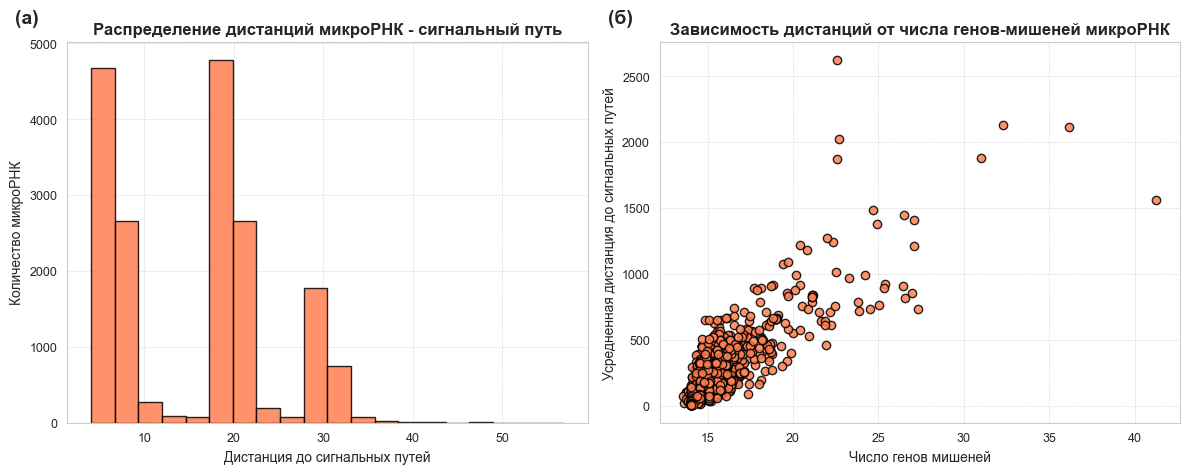

In [50]:
global_dist = []
for path in result.keys():
    if path == 'R-HSA-202127':
        continue
    for miR, w in result[path].items():
        global_dist.append(w)

res_w = []
res_mir = []
for path in result.keys():
    if path == 'R-HSA-202127':
        continue
    if path == 'R-HSA-194138.4':
        continue
    w_list = []
    card_miR = []
    for miR, w in result[path].items():
        w_list.append(w)
        card_miR.append(len(miRTargets.get_targets(miR, verbose=False)))
    res_w.append(w_list)
    res_mir.append(card_miR)

x = np.array(res_w).mean(axis=0)
y = np.array(res_mir).mean(axis=0)

mask = x < 998

fig, ax = plt.subplots(1, 2, figsize=(12, 5))  # 4 строки, 2 столбца

# Первый сабплот - гистограмма
ax[0].hist(np.array(global_dist)[np.array(global_dist) != 999], **hist_param)
ax[0].set_title('Распределение дистанций микроРНК - сигнальный путь', **title_param)
ax[0].set_xlabel('Дистанция до сигнальных путей', **label_param)
ax[0].set_ylabel('Количество микроРНК', **label_param)
ax[0].tick_params(**ticks_param)
ax[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
# Добавление плашки (а)
ax[0].text(-0.1, 1.05, "(а)", transform=ax[0].transAxes, fontsize=14, fontweight='bold')

# Второй сабплот - точечный график
ax[1].scatter(x[mask], y[mask], **scatter_param)  # Подставить нужные данные
ax[1].set_title('Зависимость дистанций от числа генов-мишеней микроРНК', **title_param)
ax[1].set_xlabel('Число генов мишеней', **label_param)
ax[1].set_ylabel('Усредненная дистанция до сигнальных путей', **label_param)
ax[1].tick_params(**ticks_param)
ax[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
# Добавление плашки (б)
ax[1].text(-0.1, 1.05, "(б)", transform=ax[1].transAxes, fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIST+"Figure1.TIFF", dpi=300, format='tiff')  # <-- Сохранение
plt.savefig(FIG_DIST+"Figure1.png", dpi=300, format='png')  # <-- Сохранение
plt.show()

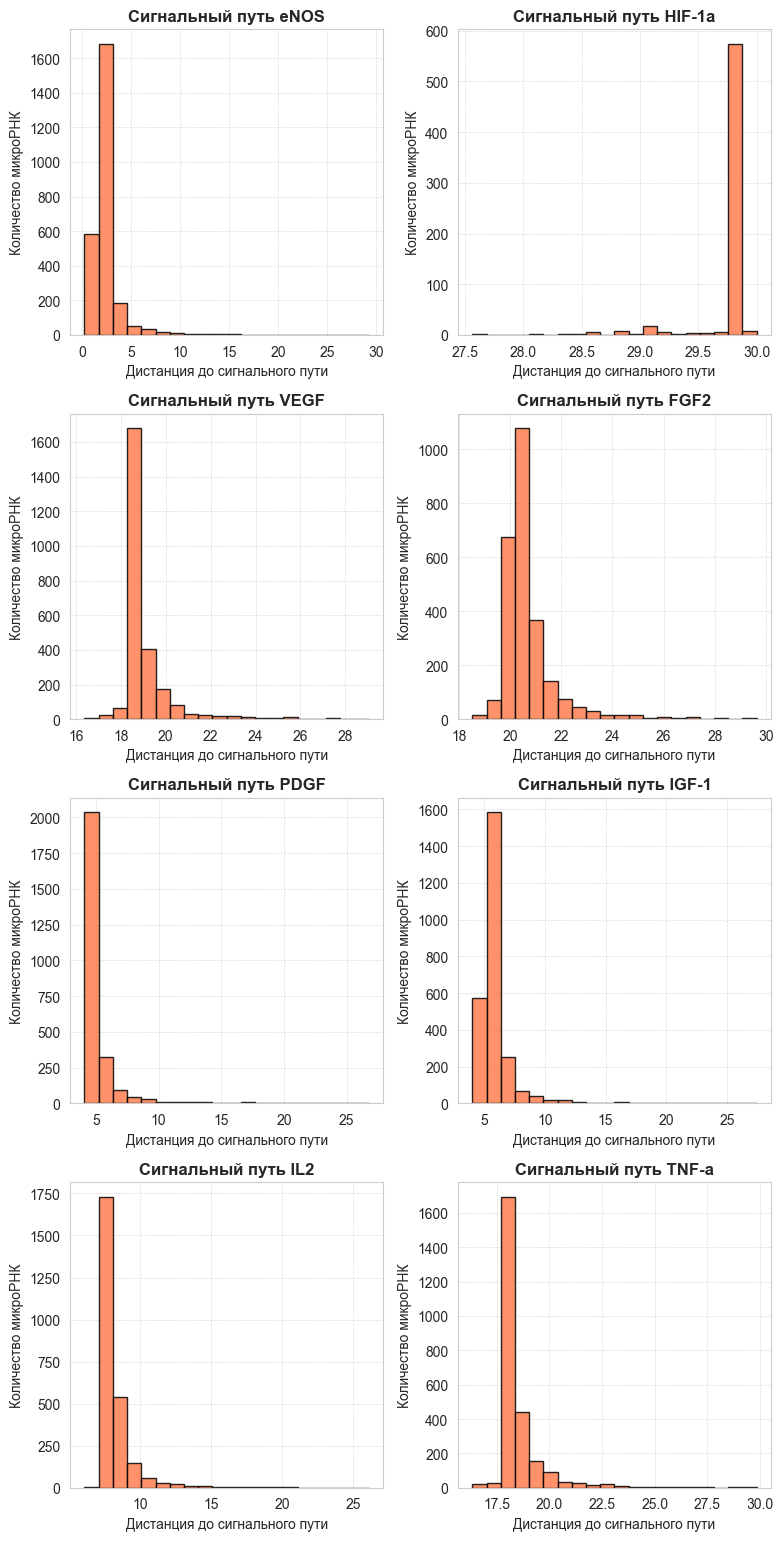

In [69]:
# Настройка фигуры
fig, axes = plt.subplots(4, 2, figsize=(8, 16))  # 4 строки, 2 столбца
axes = axes.flatten()

# Построение графиков
for i, (group, values) in enumerate(result.items()):
    ax = axes[i]

    # Фильтрация: оставляем только значения < 3
    filtered_values = [v for v in values.values() if v < 30]

    ax.hist(filtered_values, **hist_param)  # можно настроить bins
    ax.set_title(pathway_names[group], **title_param)
    ax.set_xlabel('Дистанция до сигнального пути', **label_param)
    ax.set_ylabel('Количество микроРНК', **label_param)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIST+"Figure2.TIFF", dpi=300, format='tiff')  # <-- Сохранение
plt.savefig(FIG_DIST+"Figure2.png", dpi=300, format='png')  # <-- Сохранение
plt.show()


In [ ]:
paths = dict.fromkeys(path_ids)
paths[path_ids[0]] = 1.7
paths[path_ids[1]] = 29.8
paths[path_ids[2]] = 17
paths[path_ids[3]] = 19
paths[path_ids[4]] = 4.2
paths[path_ids[5]] = 5
paths[path_ids[6]] = 7
paths[path_ids[7]] = 17

In [143]:
miR_path_miR = dict()
miR_path_w = dict()

for path in result.keys():
    miR_path_miR[path] = dict()
    miR_path_w[path] = dict()
    if path == 'R-HSA-202127':
        continue
    max_inteesec = 0
    max_w = 0
    sorted_dict = dict(sorted(result[path].items(), key=lambda item: item[1], reverse=False))
    for miR, w in sorted_dict.items():
        global_dist.append(w)
        miR_targets = set(miRTargets.get_targets(miR, verbose=False))
        path_gene = set(reactome_db[path])
        common_genes = path_gene.intersection(miR_targets)
        if common_genes == 0:
            continue
        if max_inteesec < len(common_genes):
            max_inteesec = len(common_genes)
            miR_path_w[path][max_inteesec] = [w]
            miR_path_miR[path][max_inteesec] = [miR]
        if max_inteesec == len(common_genes):
            miR_path_w[path][max_inteesec].append(w)
            miR_path_miR[path][max_inteesec].append(miR)

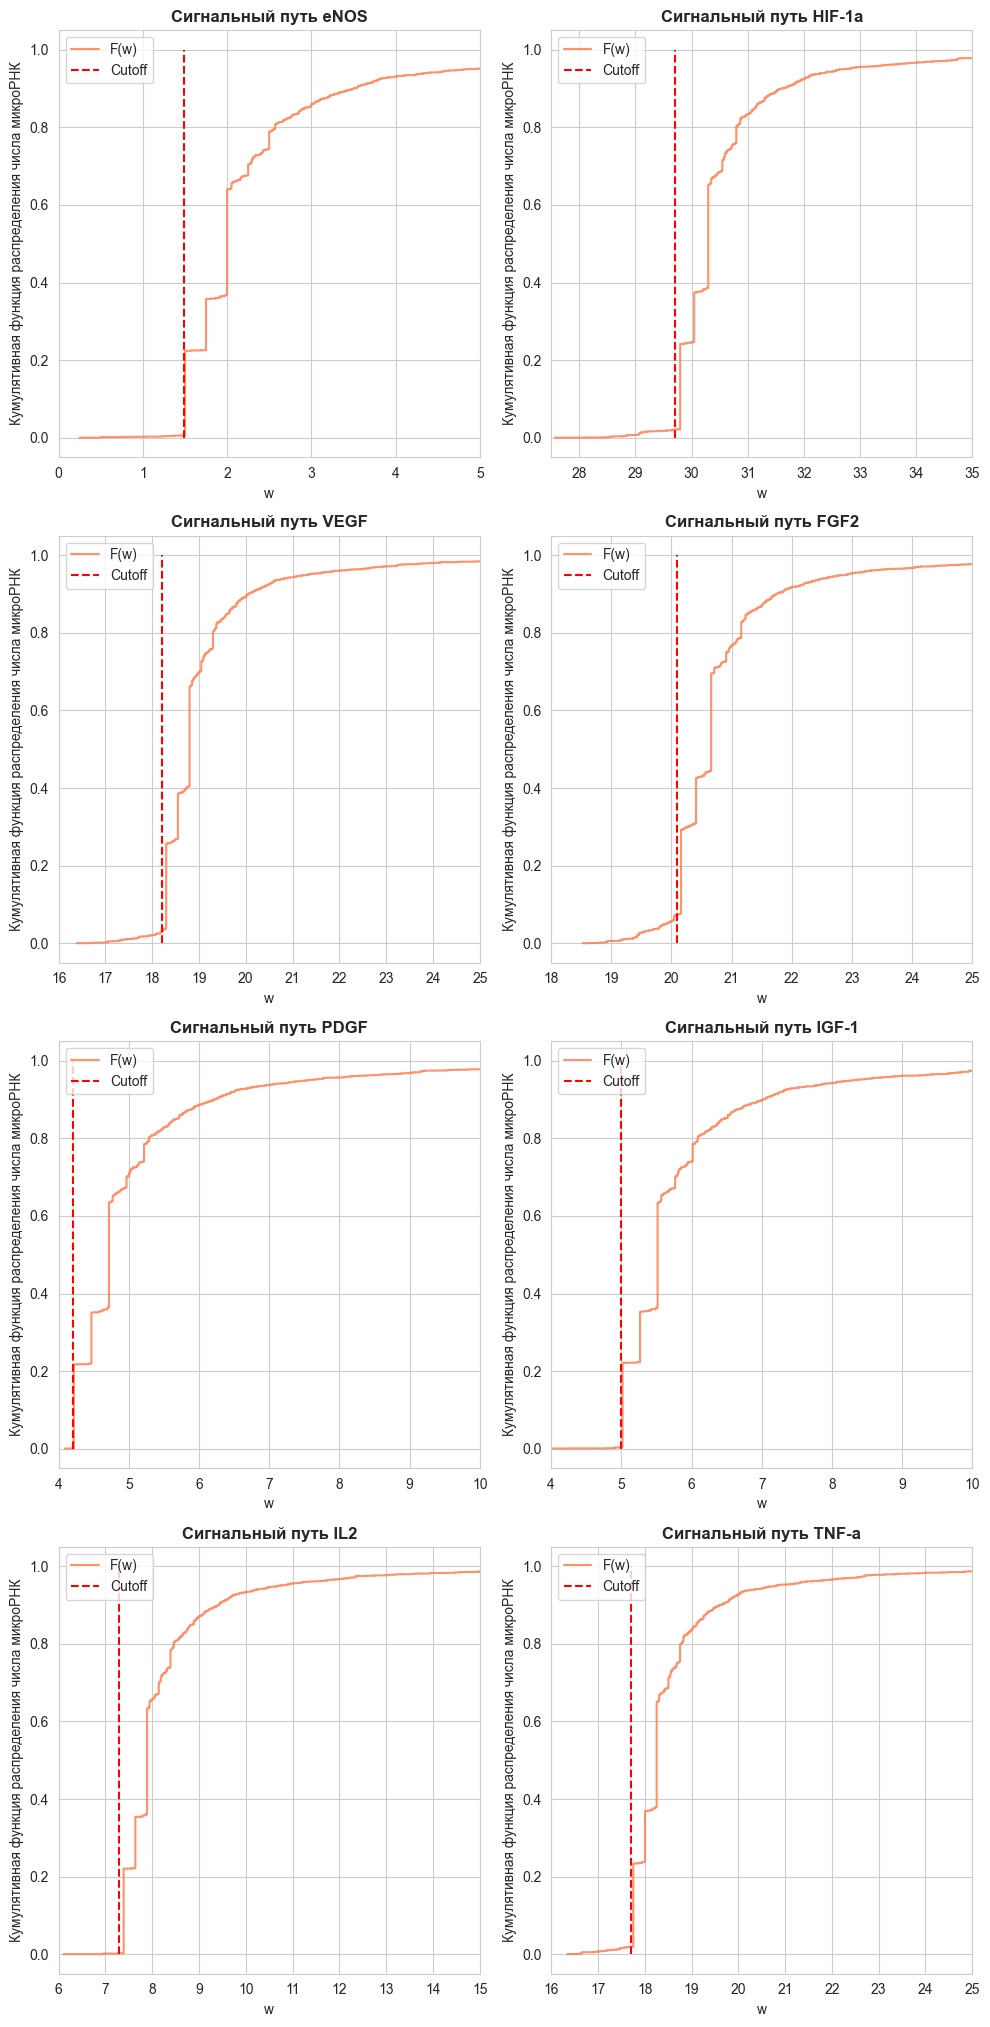

In [ ]:
paths = dict.fromkeys(path_ids)
paths[path_ids[0]] = 1.49
paths[path_ids[1]] = 29.7
paths[path_ids[2]] = 18.2
paths[path_ids[3]] = 20.1
paths[path_ids[4]] = 4.2
paths[path_ids[5]] = 4.99
paths[path_ids[6]] = 7.3
paths[path_ids[7]] = 17.7

x_limits = dict.fromkeys(path_ids)
x_limits[path_ids[0]] = (0, 5)
x_limits[path_ids[1]] = (27.5, 35)
x_limits[path_ids[2]] = (16, 25)
x_limits[path_ids[3]] = (18, 25)
x_limits[path_ids[4]] = (4, 10)
x_limits[path_ids[5]] = (4, 10)
x_limits[path_ids[6]] = (6, 15)
x_limits[path_ids[7]] = (16, 25)

# Создаём фигуру с 8 подграфиками (2 строки × 4 столбца)
fig, axes = plt.subplots(4, 2, figsize=(10, 21))
axes = axes.flatten()  # Преобразуем в плоский массив для удобства

# Перебираем пути и строим графики
for i, (path, ax) in enumerate(zip(paths.keys(), axes)):
    # Получаем данные для текущего пути (исключаем значения >= 900)
    data = np.array([v for k, v in result[path].items() if v < 900])
    n = len(data)
    
    if n == 0:
        print(f"Нет данных для пути {path} (все значения >= 900)")
        continue
    
    # Сортируем данные для ECDF
    x = np.sort(data)
    y = np.arange(1, n+1) / n
    
    # Строим ECDF
    ax.step(x, y, where='post', label='F(w)', **line_param)
    
    # Добавляем вертикальную линию
    vertical_jump = paths[path]
    ax.vlines(vertical_jump, 0, 1, colors='red', linestyles='dashed', label='Cutoff')
    
    # Настройки графика
    ax.set_title(pathway_names[path], **title_param)
    ax.set_xlabel('w', **label_param)
    ax.set_ylabel('Кумулятивная функция распределения числа микроРНК', **label_param)
    ax.set_xlim(x_limits[path][0], x_limits[path][1])
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIST+"Figure3.TIFF", dpi=300, format='tiff')  # <-- Сохранение
plt.savefig(FIG_DIST+"Figure3.png", dpi=300, format='png')  # <-- Сохранение
plt.show()

In [ ]:
path_count_cutoff = dict.fromkeys(path_ids)
path_count_cutoff[path_ids[0]] = 0
path_count_cutoff[path_ids[1]] = 2
path_count_cutoff[path_ids[2]] = 4
path_count_cutoff[path_ids[3]] = 3
path_count_cutoff[path_ids[4]] = 0
path_count_cutoff[path_ids[5]] = 1
path_count_cutoff[path_ids[6]] = 0
path_count_cutoff[path_ids[7]] = 3

zero_miR = []
print('микроРНК', 'Число генов-мишеней', 'дистанция до сигнального пути', 'гены-мишени сигнального пути', sep='\t')
for path in result.keys():
    if path == 'R-HSA-202127':
        continue
    print(path)
    count=0
    for miR, w in result[path].items():
        global_dist.append(w)
        miR_targets = set(miRTargets.get_targets(miR, verbose=False))
        path_gene = set(reactome_db[path])
        if len(path_gene.intersection(miR_targets)) > path_count_cutoff[path]:
            if paths[path] > w > 0:
                print(miR, len(miR_targets), round(w, 2), path_gene.intersection(miR_targets), sep='\t')
                count+=1
                zero_miR.append(miR)
    #print(count)

микроРНК	Число генов-мишеней	дистанция до сигнального пути	гены-мишени сигнального пути
R-HSA-1234174.5
hsa-miR-301a-3p	395	29.4	{'UBC', 'UBB', 'RPS27A'}
hsa-miR-147a	149	29.07	{'PSMA3', 'VEGFA', 'HIF3A'}
hsa-miR-301b-3p	375	29.22	{'UBC', 'UBB', 'RPS27A'}
hsa-miR-454-3p	396	29.19	{'UBC', 'UBB', 'RPS27A'}
hsa-miR-4295	366	29.14	{'UBC', 'UBB', 'RPS27A'}
hsa-miR-3666	364	29.14	{'UBC', 'UBB', 'RPS27A'}
hsa-miR-653-5p	76	27.56	{'UBC', 'SEM1', 'RPS27A'}
R-HSA-194138.4
hsa-miR-374b-5p	234	17.28	{'AKT1', 'NRP2', 'PRKCD', 'VEGFA', 'RAC1'}
hsa-miR-369-3p	163	17.45	{'NRP2', 'PRKCD', 'VEGFA', 'RAC1', 'PLCG1'}
R-HSA-190236.4
hsa-miR-3652	397	18.77	{'GTF2F1', 'POLR2D', 'POLR2E', 'MAPK1'}
hsa-miR-4430	397	18.77	{'GTF2F1', 'POLR2D', 'POLR2E', 'MAPK1'}
hsa-miR-6134	360	19.43	{'GTF2F1', 'FGFR1', 'POLR2E', 'FGF19'}
R-HSA-186797.6
hsa-miR-155-3p	68	4.09	{'PLCG1'}
hsa-miR-196b-3p	16	4.1	{'SOS1'}
R-HSA-2404192.5
hsa-miR-2117	57	4.79	{'PIK3CB', 'PDPK1'}
hsa-miR-3191-5p	94	4.9	{'IGF1R', 'PDPK1'}
R-HSA-451927.